**Import Required Libraries**

In [1]:
from keras import models
from keras import layers
from keras.utils import to_categorical
from keras.datasets import fashion_mnist

**Import and Install livelossplot**

In [2]:
!pip install livelossplot
from livelossplot import PlotLossesKeras

In [3]:
def data_summary(x_train, y_train, x_test, y_test):
  print("Train Image Shape: ", x_train.shape)
  print("Test Image Shape: ", y_train.shape)
  print("Train Label Shape: ", x_test.shape)
  print("Test Label shape: ", y_test.shape)
  print("Train labels: ", y_train)
  print("Test labels: ", y_test)

**Load Dataset**

In [4]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Data Visualization and preprocessing**

In [5]:
data_summary(x_train, y_train, x_test, y_test)

Train Image Shape:  (60000, 28, 28)
Test Image Shape:  (60000,)
Train Label Shape:  (10000, 28, 28)
Test Label shape:  (10000,)
Train labels:  [9 0 0 ... 3 0 5]
Test labels:  [9 2 1 ... 8 1 5]


In [6]:
x_train[2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,  22, 118,  24,   0,
          0,   0,   0,   0,  48,  88,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  12, 100, 212, 205, 185,
        179, 173, 186, 193, 221, 142,  85,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  85,  76, 199, 225,
        248, 255, 238, 226, 157,  68,  80,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  91,  69,  91, 201,
        218, 225, 209, 158,  61,  93,  72,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  79,  89,  61,  59,
         87, 108,  75,  56,  76,  97,  73,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  75,  89,  80,  80,
         67,  63,  73,  83,  80,  96,  72,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  77,  88,  77,  80,
         83,  83,  83,  83,  81,  95,  76,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  89,  96,  80,  83,
         81,  84,  85,  85,  85,  97,  84,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  93,  97,  81,  85,
         84,  85,  87,  88,  84,  99,  87,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  95,  87,  84,  87,
         88,  85,  87,  87,  84,  92,  87,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  97,  87,  87,  85,
         88,  87,  87,  87,  88,  85, 107,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  17, 100,  88,  87,  87,
         88,  87,  87,  85,  89,  77, 118,   8,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  10,  93,  87,  87,  87,
         87,  87,  88,  87,  89,  80, 103,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   9,  96,  87,  87,  87,
         87,  87,  88,  87,  88,  87, 103,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  12,  96,  85,  87,  87,
         87,  85,  87,  87,  88,  89, 100,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  20,  95,  84,  88,  85,
         87,  88,  88,  88,  89,  88,  99,   8,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  21,  96,  85,  87,  85,
         88,  88,  88,  88,  89,  89,  99,  10,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  24,  96,  85,  87,  85,
         87,  88,  88,  89,  88,  91, 102,  14,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  25,  93,  84,  88,  87,
         87,  87,  87,  87,  89,  91, 103,  29,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  95,  85,  88,  88,
         87,  87,  87,  87,  89,  88, 102,  37,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  34,  96,  88,  87,  87,
         87,  87,  87,  87,  85,  85,  97,  38,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  40,  96,  87,  85,  87,
         87,  87,  87,  87,  85,  84,  92,  49,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  46,  95,  83,  84,  87,
         87,  87,  87,  87,  87,  84,  87,  84,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  72,  95,  85,  84,  85,
         88,  87,  87,  89,  87,  85,  83,  63,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [7]:
y_train[2]

0

Train label -----------------------> 0


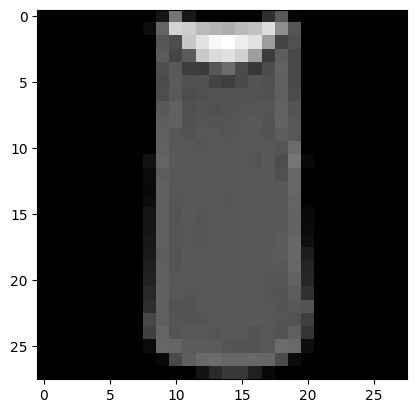

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

Sample = 2
print("Train label ----------------------->", y_train[Sample])
image = x_train[Sample]

#plot the sample
fig = plt.figure
plt.imshow(image, cmap='gray')
plt.show()

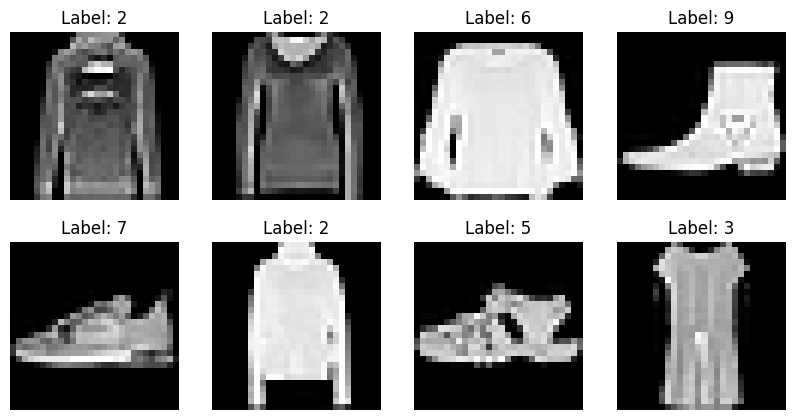

In [9]:
# prompt: use the above code to plot 8 random images from train data along with it's actual label

import matplotlib.pyplot as plt
import random
# select 8 random images from train data
fig = plt.figure(figsize=(10,5))
for i in range(8):
  ax = plt.subplot(2, 4, i+1)
  Sample = random.randint(0,59999)
  image = x_train[Sample]
  #plot the sample
  plt.imshow(image, cmap='gray')
  plt.title(f"Label: {y_train[Sample]}")
  plt.axis("off")

plt.show()


In [10]:
import numpy as np
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [11]:
# Define some variables

num_col = 28
num_row = 28
num_classes = 10
batch_size = 128
epochs = 250

**Reshape the data**

In [12]:
data_summary(x_train, y_train, x_test, y_test)

Train Image Shape:  (60000, 28, 28)
Test Image Shape:  (60000,)
Train Label Shape:  (10000, 28, 28)
Test Label shape:  (10000,)
Train labels:  [9 0 0 ... 3 0 5]
Test labels:  [9 2 1 ... 8 1 5]


In [13]:
x_train = x_train.reshape(x_train.shape[0], num_row * num_col)
x_test = x_test.reshape(x_test.shape[0], num_row * num_col)

In [14]:
data_summary(x_train, y_train, x_test, y_test)

Train Image Shape:  (60000, 784)
Test Image Shape:  (60000,)
Train Label Shape:  (10000, 784)
Test Label shape:  (10000,)
Train labels:  [9 0 0 ... 3 0 5]
Test labels:  [9 2 1 ... 8 1 5]


**Scaling of the data**

In [15]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [16]:
data_summary(x_train, y_train, x_test, y_test)

Train Image Shape:  (60000, 784)
Test Image Shape:  (60000,)
Train Label Shape:  (10000, 784)
Test Label shape:  (10000,)
Train labels:  [9 0 0 ... 3 0 5]
Test labels:  [9 2 1 ... 8 1 5]


**Encoding the target data**
* One hot encoding

In [17]:
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [18]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [19]:
data_summary(x_train, y_train, x_test, y_test)

Train Image Shape:  (60000, 784)
Test Image Shape:  (60000, 10)
Train Label Shape:  (10000, 784)
Test Label shape:  (10000, 10)
Train labels:  [[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Test labels:  [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


# **Model Architecture and Development**

In [20]:
# Buidling Model

model = models.Sequential()
model.add(layers.Dense(128, activation='relu', input_dim=784))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
lr = 0.01

from tensorflow.keras.optimizers import SGD
sgd = SGD(learning_rate=lr)

In [23]:
# compile model
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
#Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

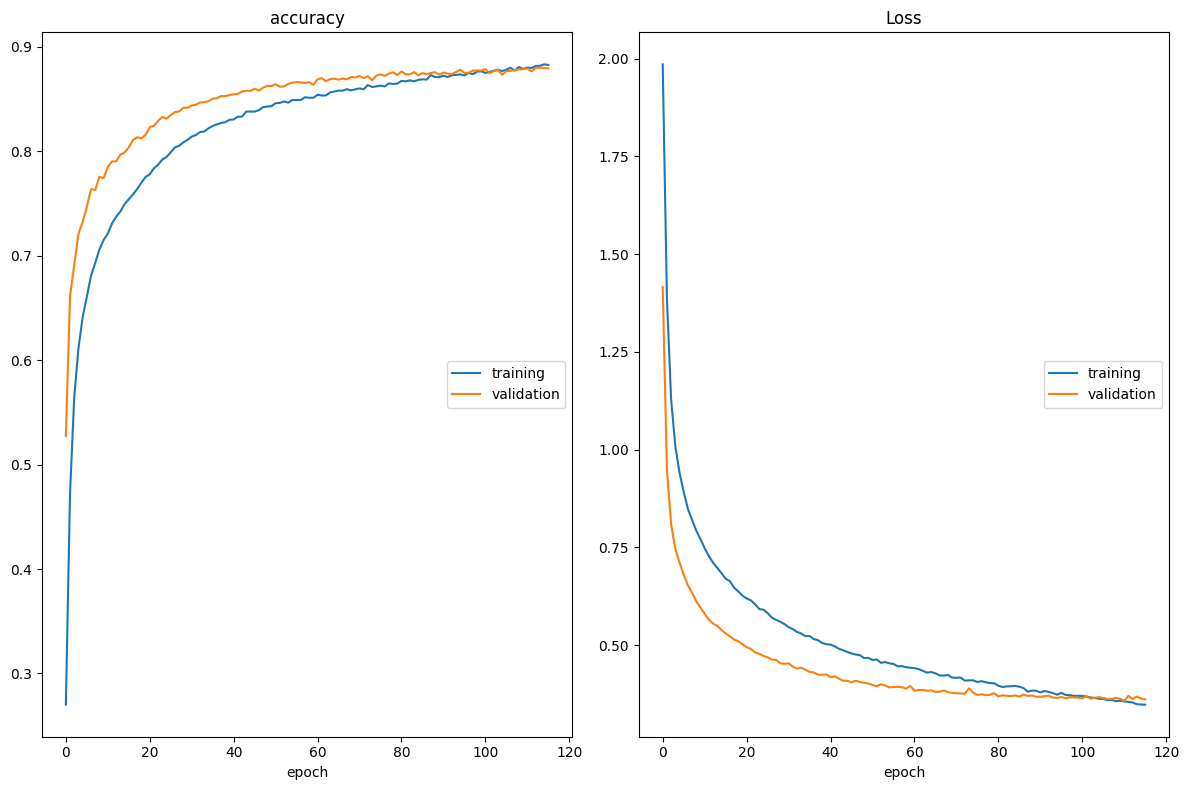

accuracy
	training         	 (min:    0.270, max:    0.883, cur:    0.883)
	validation       	 (min:    0.527, max:    0.880, cur:    0.880)
Loss
	training         	 (min:    0.347, max:    1.986, cur:    0.347)
	validation       	 (min:    0.357, max:    1.416, cur:    0.361)
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8845 - loss: 0.3455 - val_accuracy: 0.8796 - val_loss: 0.3613


In [25]:
model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test), callbacks=[PlotLossesKeras(), early_stopping], verbose=1)

In [26]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.357077032327652
Test accuracy: 0.8794999718666077


In [27]:
prediction = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:
prediction[10]

array([6.0075217e-05, 8.8598405e-05, 1.3949259e-01, 8.7373087e-04,
       7.8191853e-01, 3.6068609e-08, 7.7430502e-02, 3.7039533e-06,
       7.3457806e-05, 5.8817601e-05], dtype=float32)

In [29]:
y_test[10]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

**Analysis**
1. With one output layer, 2 hidden layer of 32 and 16 Neurons and 1 output layer accuracy stabilize to around 88% after 70 epochs at learning rate of 0.01.
2. With same setup after changing learning rate to 0.1 model performance further decreased.
3. After further increasing the complexity of model with hidden layer neurons of 64, 32 and 16 with learning rate of 0.1 model performance further improved to 90% and 86% on training and testing data showing some overfitting to training data.
4. Further increasing hidden layers with 128, 256, 512 neurons doesn't help much.

**After Adding Dropout layers @10% dropout**  
5. with 6 hidden layers with 512, 256, 128, 64, 32, 16 neurons I have got around same accuracy
6. Same goes with 5 hidden layers with 256, 128, 64, 32 and 16 neurons. Accuracy doen't improve much and models seems to be overfitting slightly.
7. With 4 hidden layers (128,64,32,16) I have got the better training and testing accuracy at 89% and 88.10%.
8. With 3 hidden layers (64,32,16) I have got training and testing accuracy of 88.5% and 88%.
9. With 2 hidden layers (32, 16) I have got training and testing accuracy of 86.9% and 86.8%.

### **Conclusion:**
Model is performing well with 4 (128,64,32,16) hidden layers and dropout rate at 10%  or 20% and learning rate of 0.01 with training and testing accurcy of around 88%.